In [126]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Style global amélioré
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
})

PALETTE = sns.color_palette("mako", 12)
SAVE_DIR = "../DataViz"
os.makedirs(SAVE_DIR, exist_ok=True)

## X_TRAIN - VIZ

In [127]:
x_train = pd.read_csv("../data/x_train_final.csv")
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [128]:
x_train["nb_arrets"] = x_train.groupby(["train", "date"])["arret"].transform("count")
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,nb_arrets
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,5
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0,5
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0,5
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,5
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,19
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0,19
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,19
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0,19


In [129]:
y_train = pd.read_csv("../data/y_train_final.csv")

In [130]:
x_train.describe()

# Unamed a tej

,Unnamed: 0.1,Unnamed: 0,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,nb_arrets
count,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000
mean,333631.500000,333631.500000,18.277499,-0.170696,-0.167304,-0.176308,-0.163223,-0.173579,-0.174436,20.244800
std,192622.669348,192622.669348,7.030424,1.976521,1.960416,1.926275,1.988527,2.643148,4.732999,5.194814
min,0.000000,0.000000,7.000000,-160.000000,-160.000000,-160.000000,-160.000000,-1441.000000,-1441.000000,1.000000
25%,166815.750000,166815.750000,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,18.000000
50%,333631.500000,333631.500000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000
75%,500447.250000,500447.250000,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23.000000
max,667263.000000,667263.000000,42.000000,14.000000,15.000000,15.000000,15.000000,15.000000,15.000000,31.000000


In [131]:
# Nan values

x_train.isna().sum()

Unnamed: 0.1    0
Unnamed: 0      0
train           0
gare            0
date            0
arret           0
p2q0            0
p3q0            0
p4q0            0
p0q2            0
p0q3            0
p0q4            0
nb_arrets       0
dtype: int64

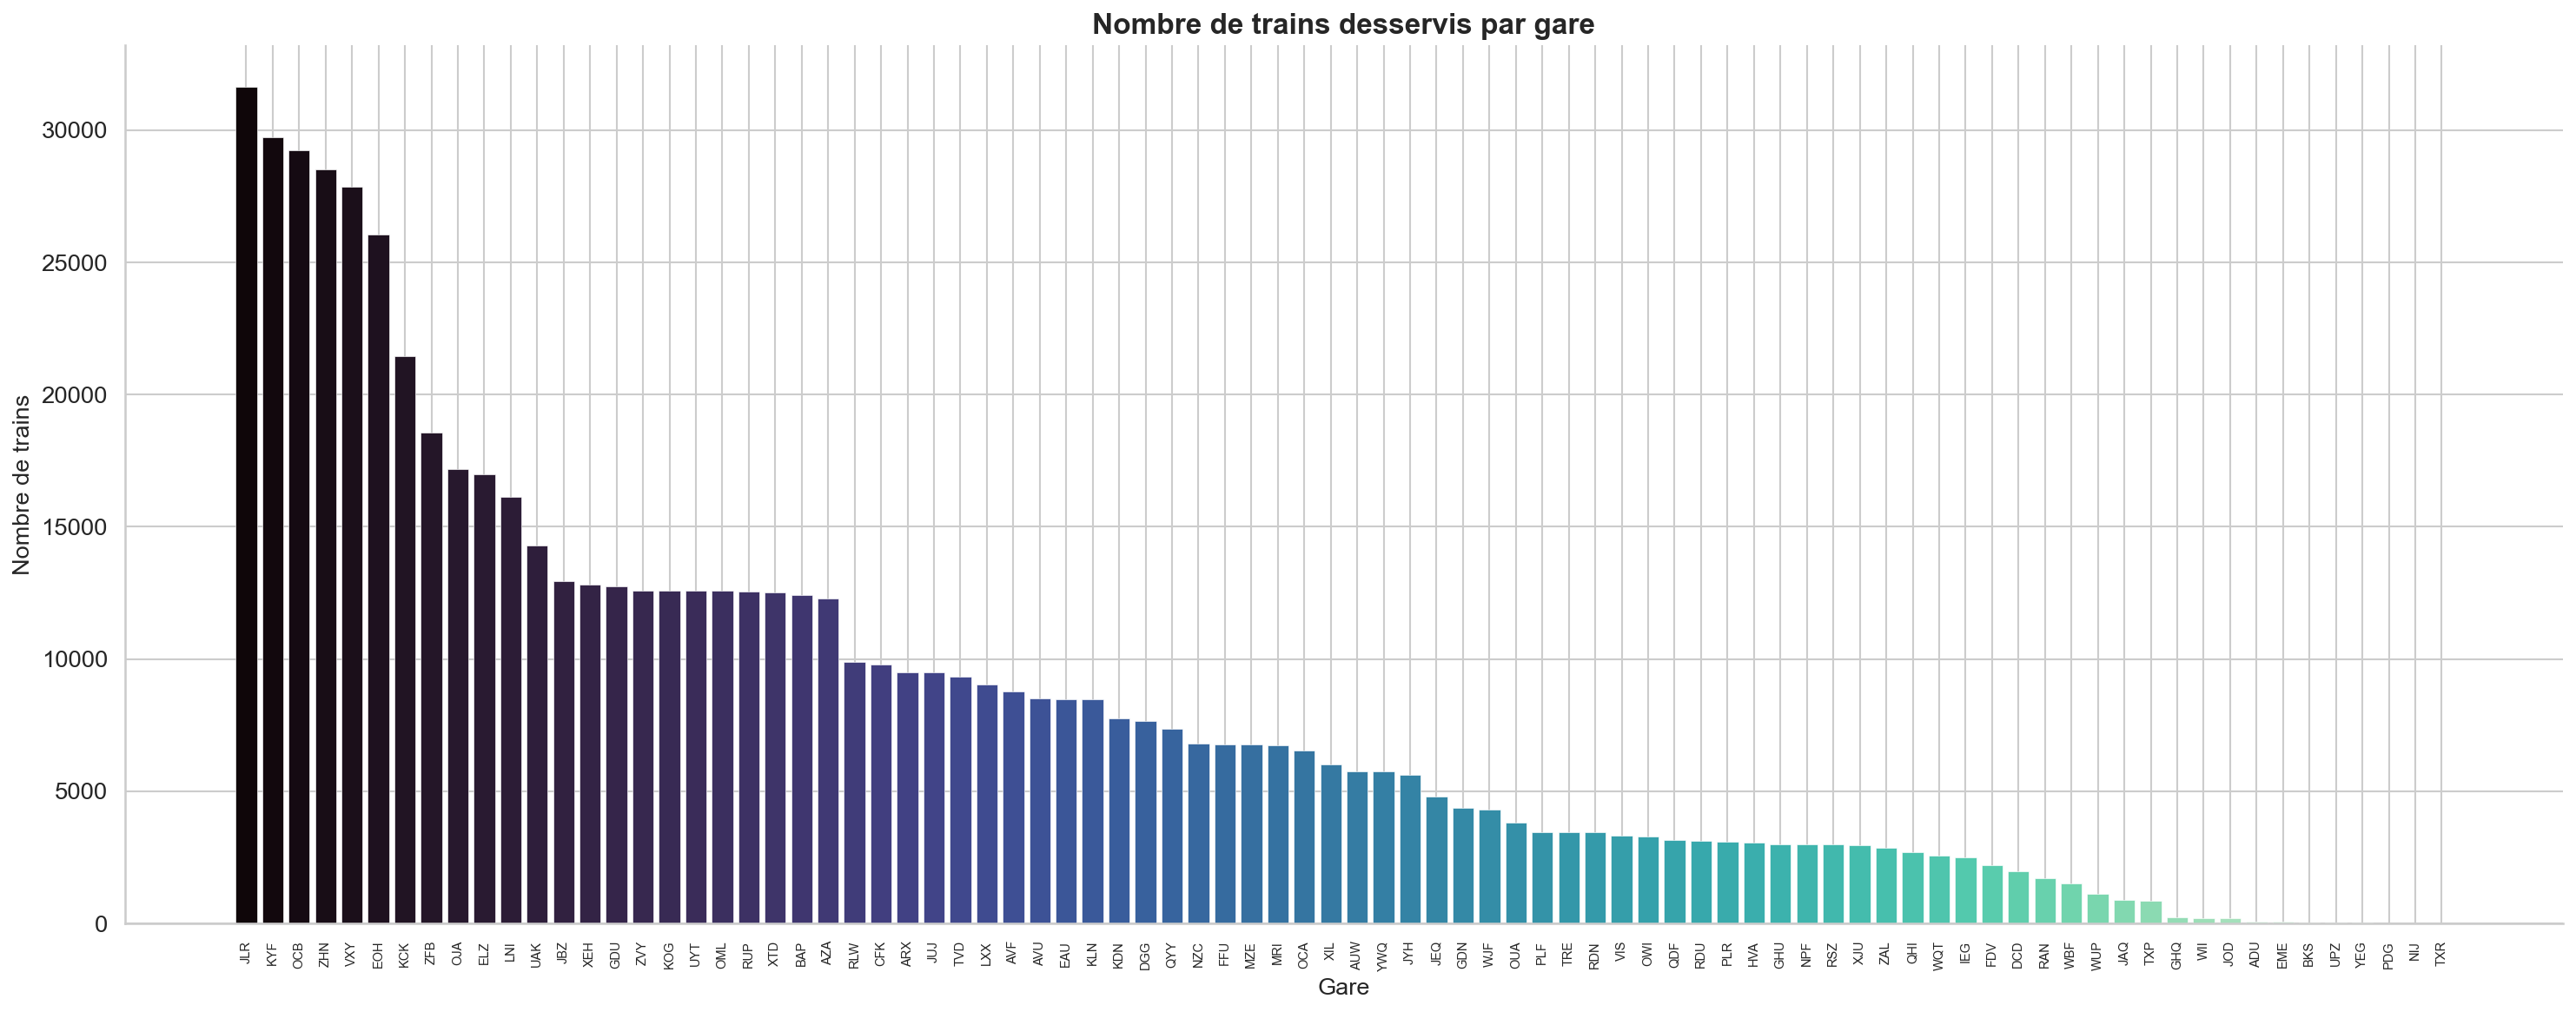

La gare ayant desservi le plus de trains est : JLR


In [132]:
fig, ax = plt.subplots(figsize=(20, 8))
gare_counts = x_train["gare"].value_counts()
colors = sns.color_palette("mako", len(gare_counts))
ax.bar(range(len(gare_counts)), gare_counts.values, color=colors, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(gare_counts)))
ax.set_xticklabels(gare_counts.index, rotation=90, fontsize=7)
ax.set_title("Nombre de trains desservis par gare")
ax.set_xlabel("Gare")
ax.set_ylabel("Nombre de trains")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/01_gares_trains.png")
plt.show()

most_served_train_station = gare_counts.index[0]
print(f"La gare ayant desservi le plus de trains est : {most_served_train_station}")

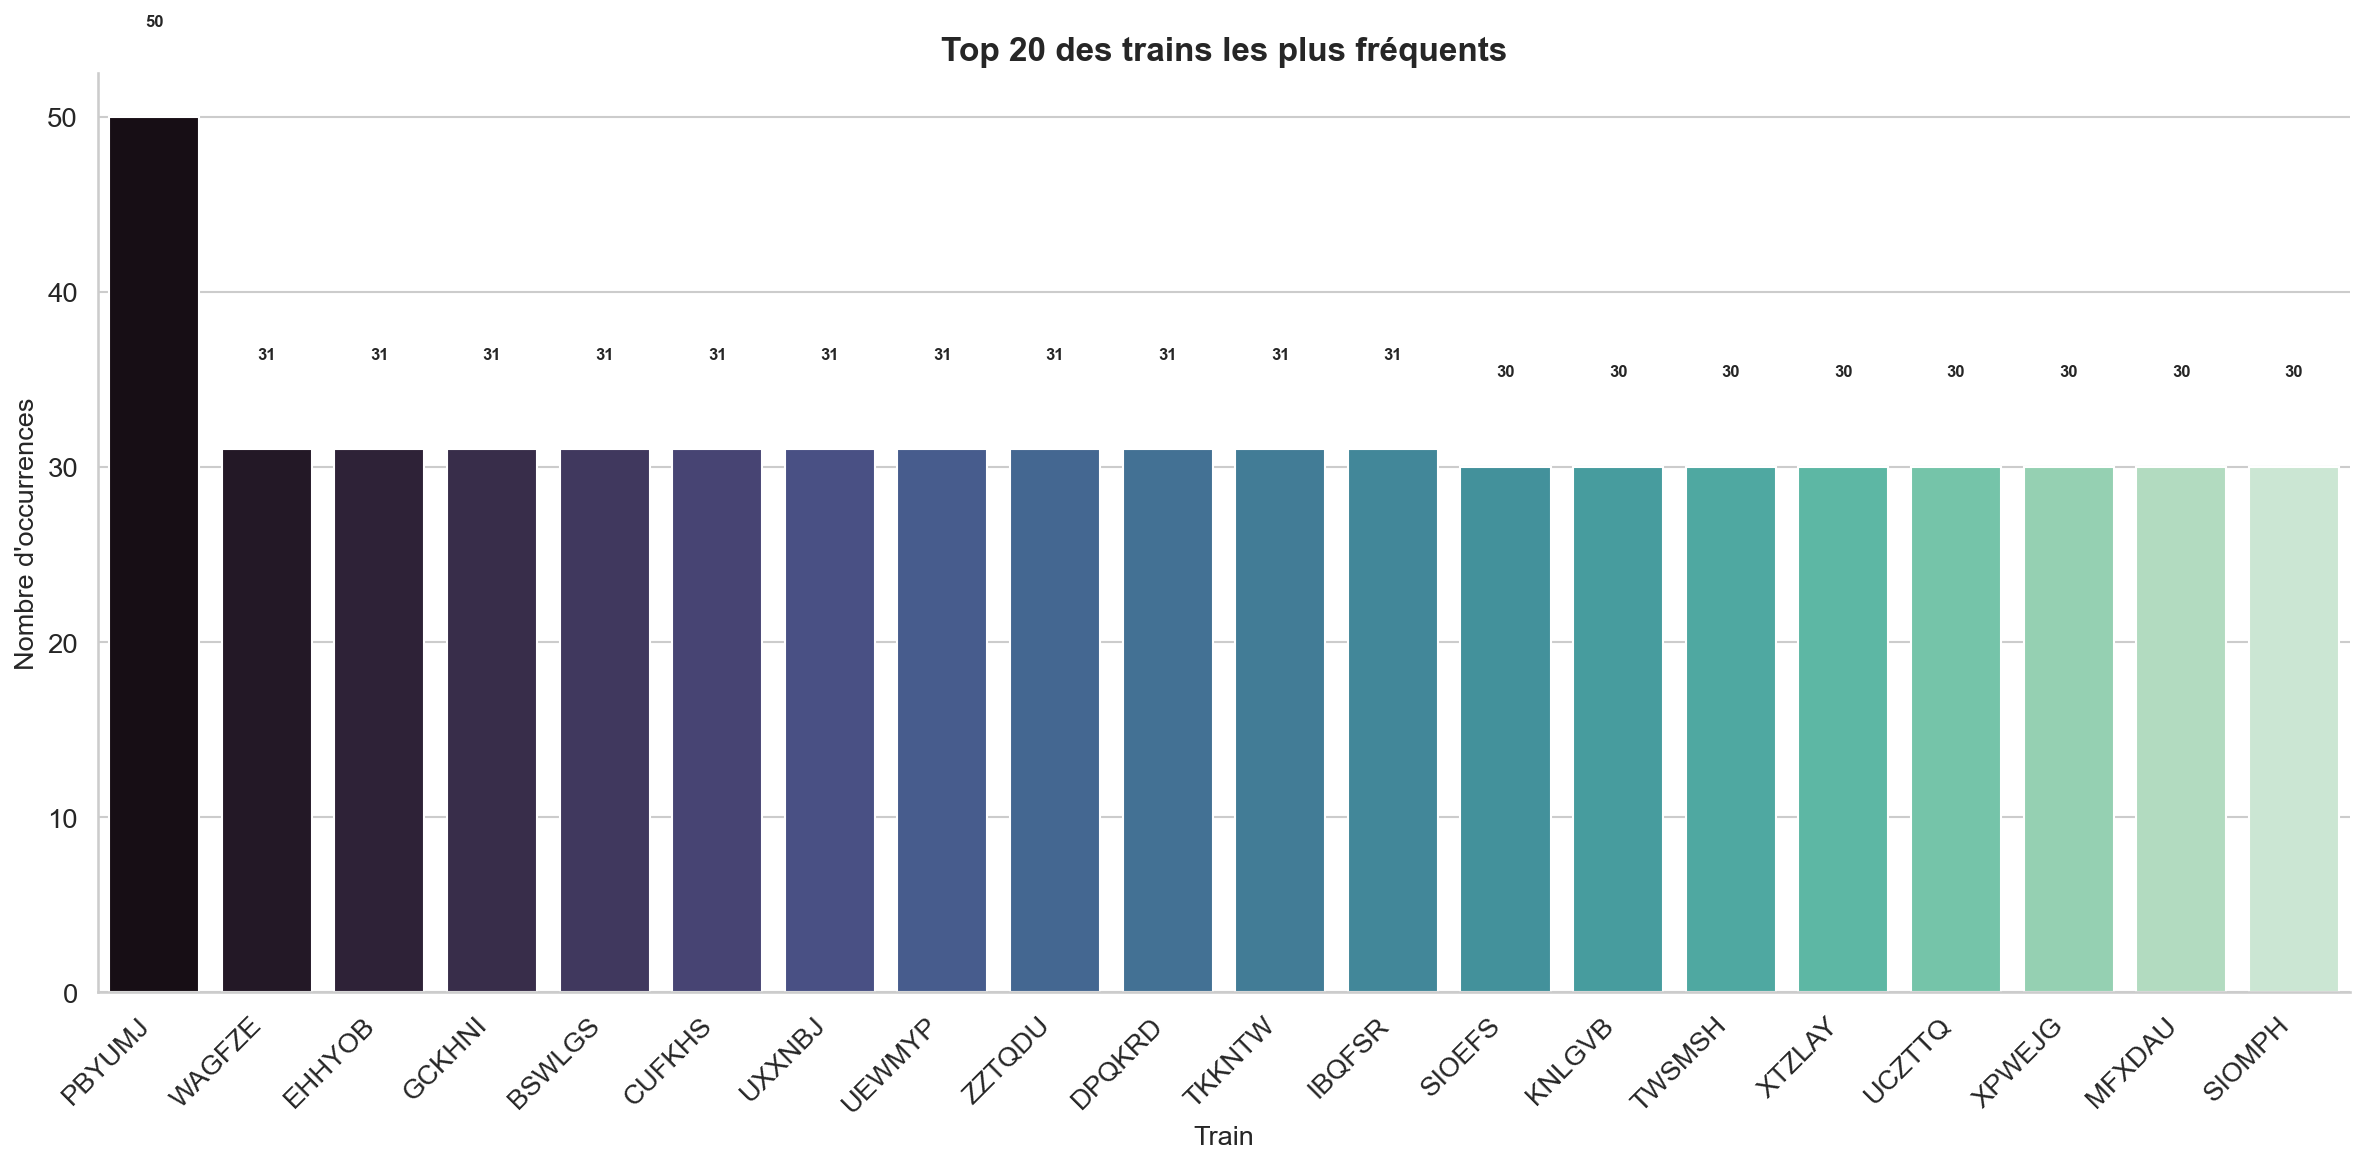

Le train le plus desservi est PBYUMJ !


In [133]:
fig, ax = plt.subplots(figsize=(16, 8))
top20_trains = x_train["train"].value_counts().head(20)
sns.barplot(x=top20_trains.index, y=top20_trains.values, palette="mako", edgecolor="white", ax=ax)
ax.set_title("Top 20 des trains les plus fréquents")
ax.set_xlabel("Train")
ax.set_ylabel("Nombre d'occurrences")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.spines[["top", "right"]].set_visible(False)
for i, v in enumerate(top20_trains.values):
    ax.text(i, v + 5, str(v), ha="center", va="bottom", fontsize=8, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/02_top20_trains.png")
plt.show()

most_served_train = top20_trains.index[0]
print(f"Le train le plus desservi est {most_served_train} !")

In [8]:
x_train[(x_train["train"] == "PBYUMJ") & (x_train["gare"] == "JLR")] # Le train PBYUMJ est desservi deux fois sur la gare JLR

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
98693,98693,98693,PBYUMJ,JLR,2023-05-09,12,0.0,0.0,0.0,0.0,0.0,1.0
236402,236402,236402,PBYUMJ,JLR,2023-06-06,23,0.0,0.0,0.0,0.0,-1.0,1.0


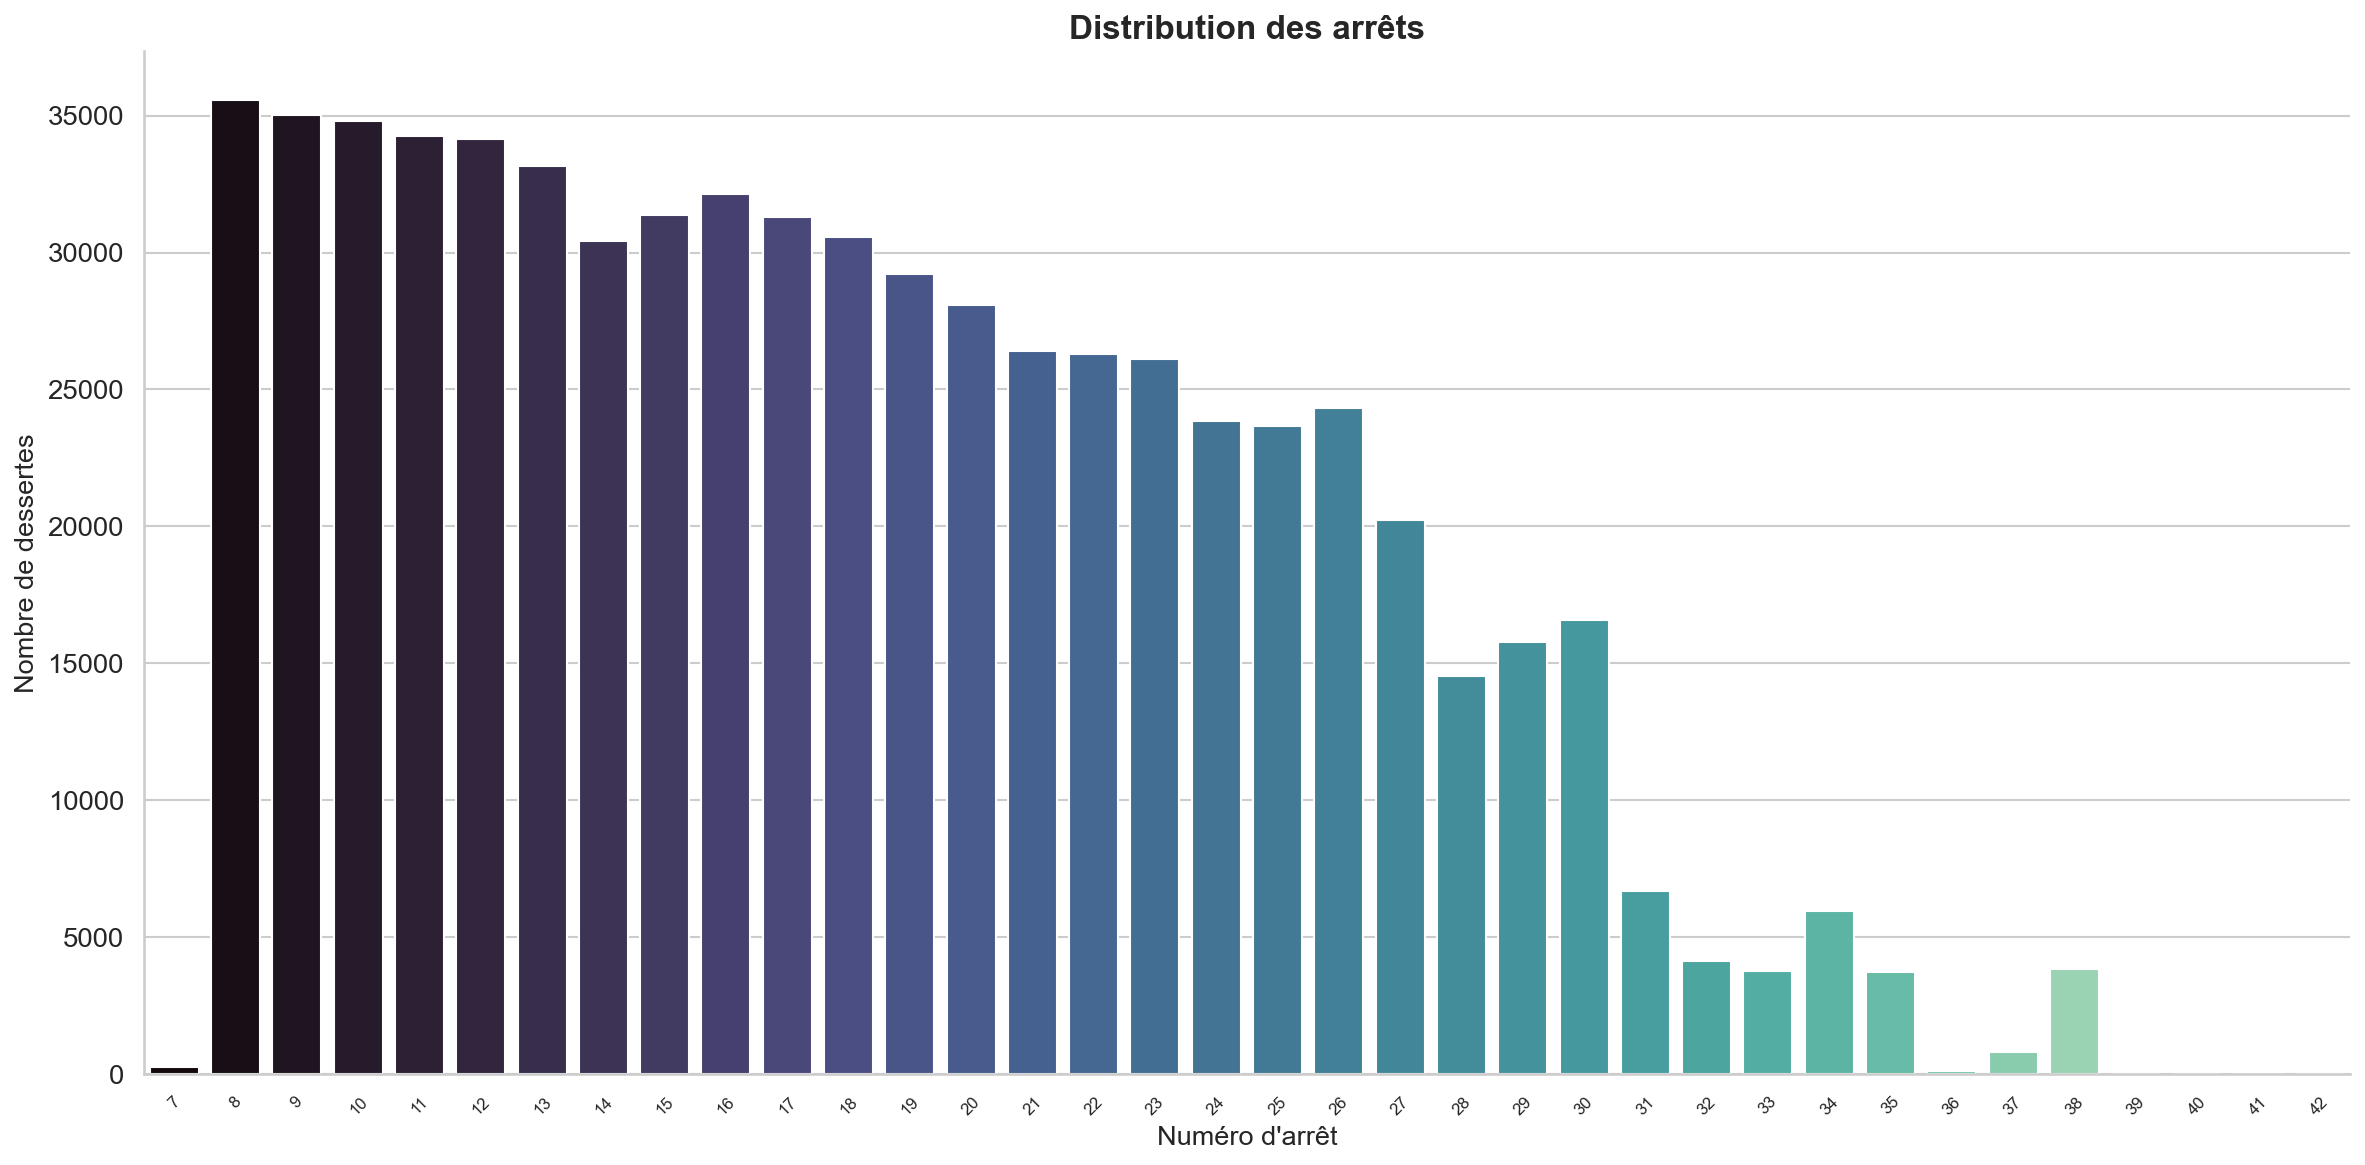

L'arrêt le plus desservi est le 8


In [134]:
fig, ax = plt.subplots(figsize=(16, 8))
arret_counts = x_train["arret"].value_counts().sort_index()
sns.barplot(x=arret_counts.index.astype(str), y=arret_counts.values, palette="mako", edgecolor="white", ax=ax)
ax.set_title("Distribution des arrêts")
ax.set_xlabel("Numéro d'arrêt")
ax.set_ylabel("Nombre de dessertes")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/03_distribution_arrets.png")
plt.show()

most_served_stop = x_train['arret'].value_counts().sort_values(ascending=False).index[0]
print(f"L'arrêt le plus desservi est le {most_served_stop}")

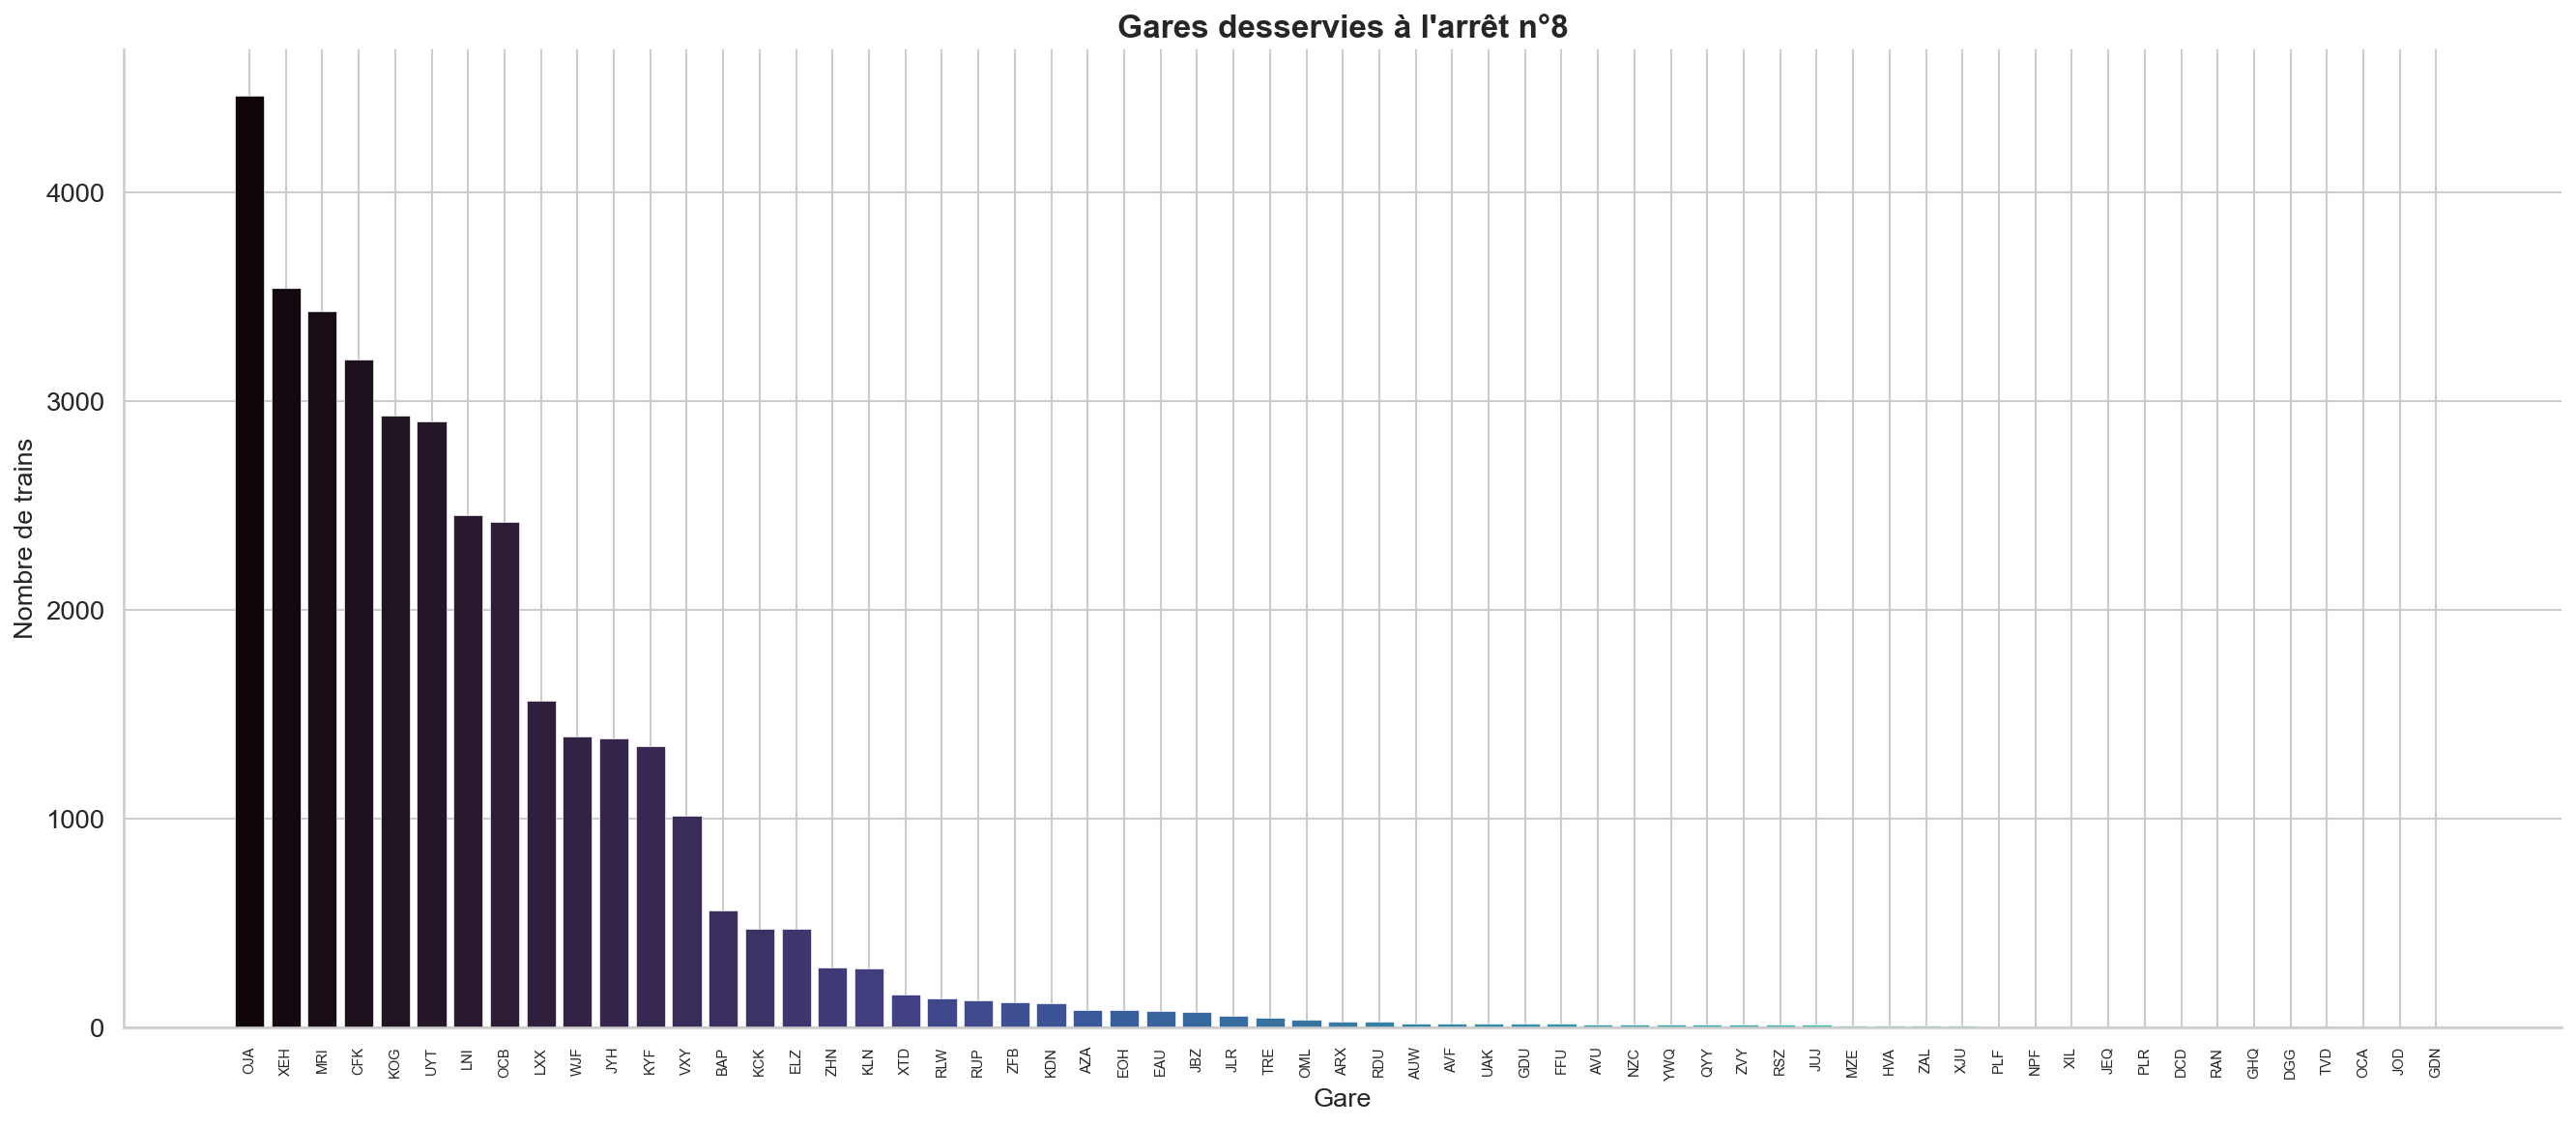

In [135]:
fig, ax = plt.subplots(figsize=(18, 8))
arret8 = x_train[x_train["arret"] == 8]["gare"].value_counts()
colors = sns.color_palette("mako", len(arret8))
ax.bar(range(len(arret8)), arret8.values, color=colors, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(arret8)))
ax.set_xticklabels(arret8.index, rotation=90, fontsize=7)
ax.set_title("Gares desservies à l'arrêt n°8")
ax.set_xlabel("Gare")
ax.set_ylabel("Nombre de trains")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/04_gares_arret8.png")
plt.show()

In [138]:
x_train["date"]  = pd.to_datetime(x_train["date"])

In [139]:
x_train["year"] = x_train["date"].dt.year
x_train["month"] = x_train["date"].dt.month
x_train["day"] = x_train["date"].dt.day
x_train["day_of_week"] = x_train["date"].dt.dayofweek

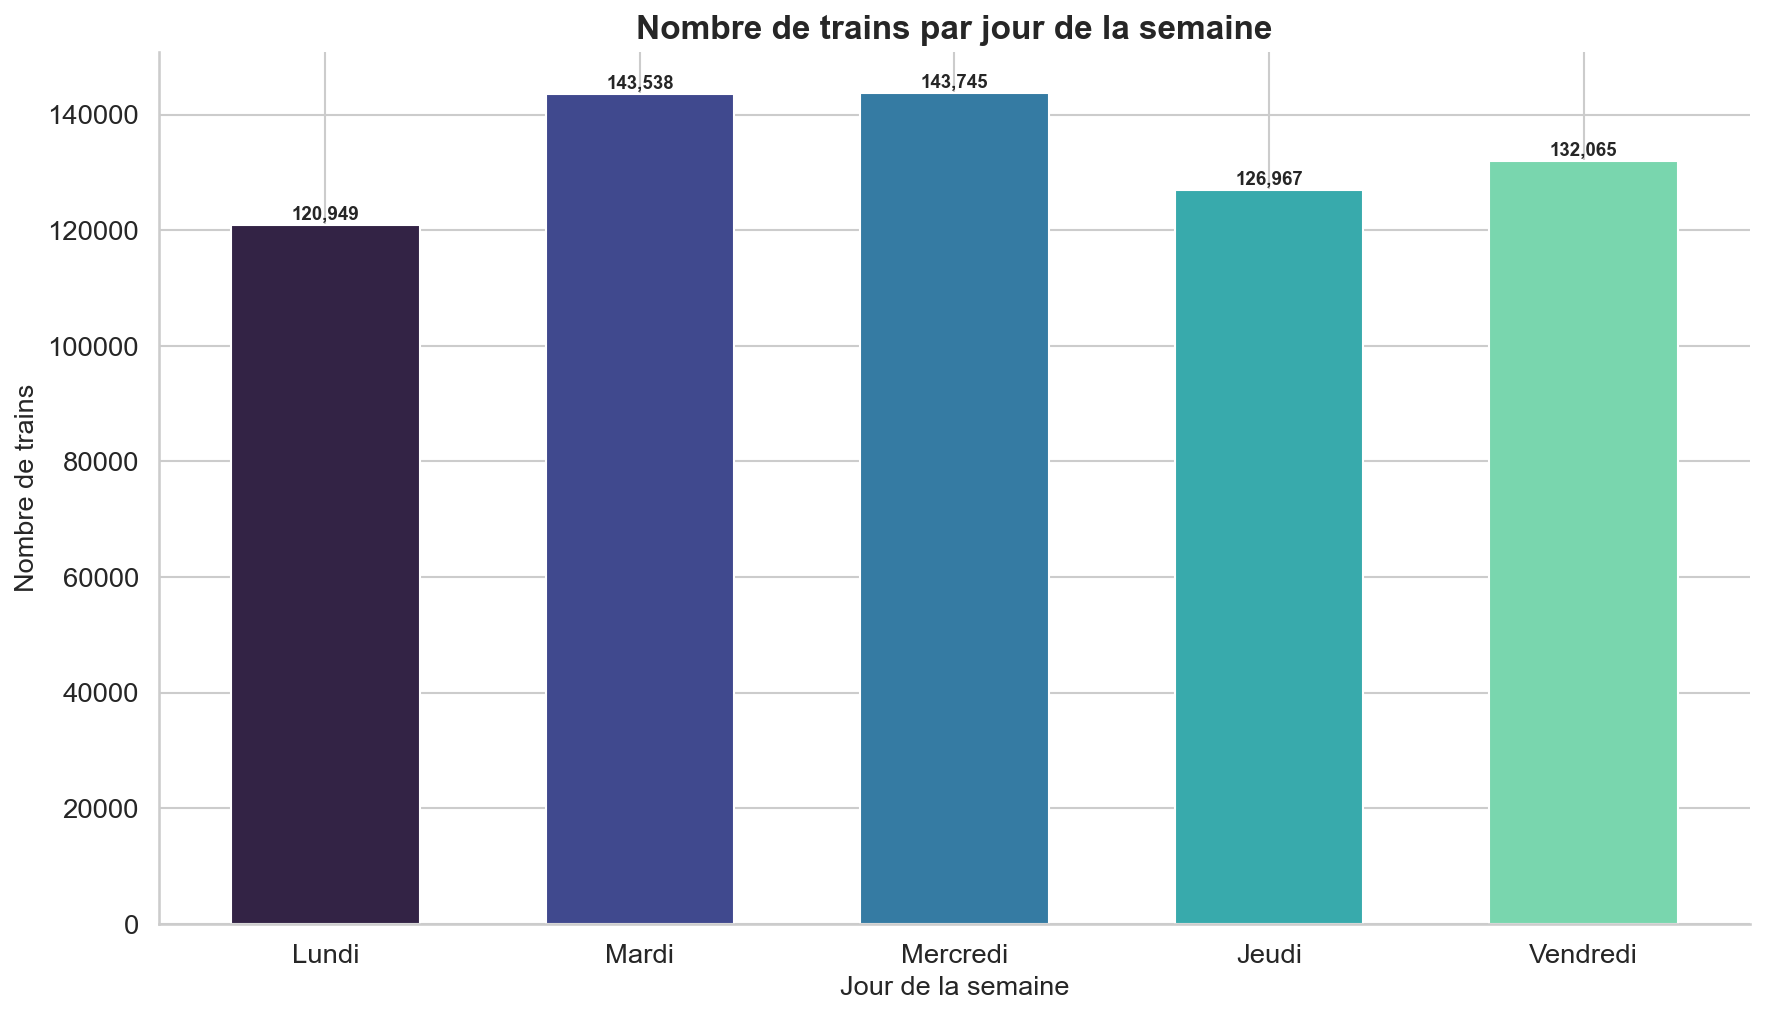

In [140]:
fig, ax = plt.subplots(figsize=(12, 7))
jours = {0: "Lundi", 1: "Mardi", 2: "Mercredi", 3: "Jeudi", 4: "Vendredi", 5: "Samedi", 6: "Dimanche"}
dow_counts = x_train["day_of_week"].value_counts().sort_index()
labels = [jours.get(d, str(d)) for d in dow_counts.index]
bars = ax.bar(labels, dow_counts.values, color=sns.color_palette("mako", len(dow_counts)), edgecolor="white", width=0.6)
ax.set_title("Nombre de trains par jour de la semaine")
ax.set_xlabel("Jour de la semaine")
ax.set_ylabel("Nombre de trains")
ax.spines[["top", "right"]].set_visible(False)
for bar, v in zip(bars, dow_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 200, f"{v:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/05_trains_par_jour.png")
plt.show()

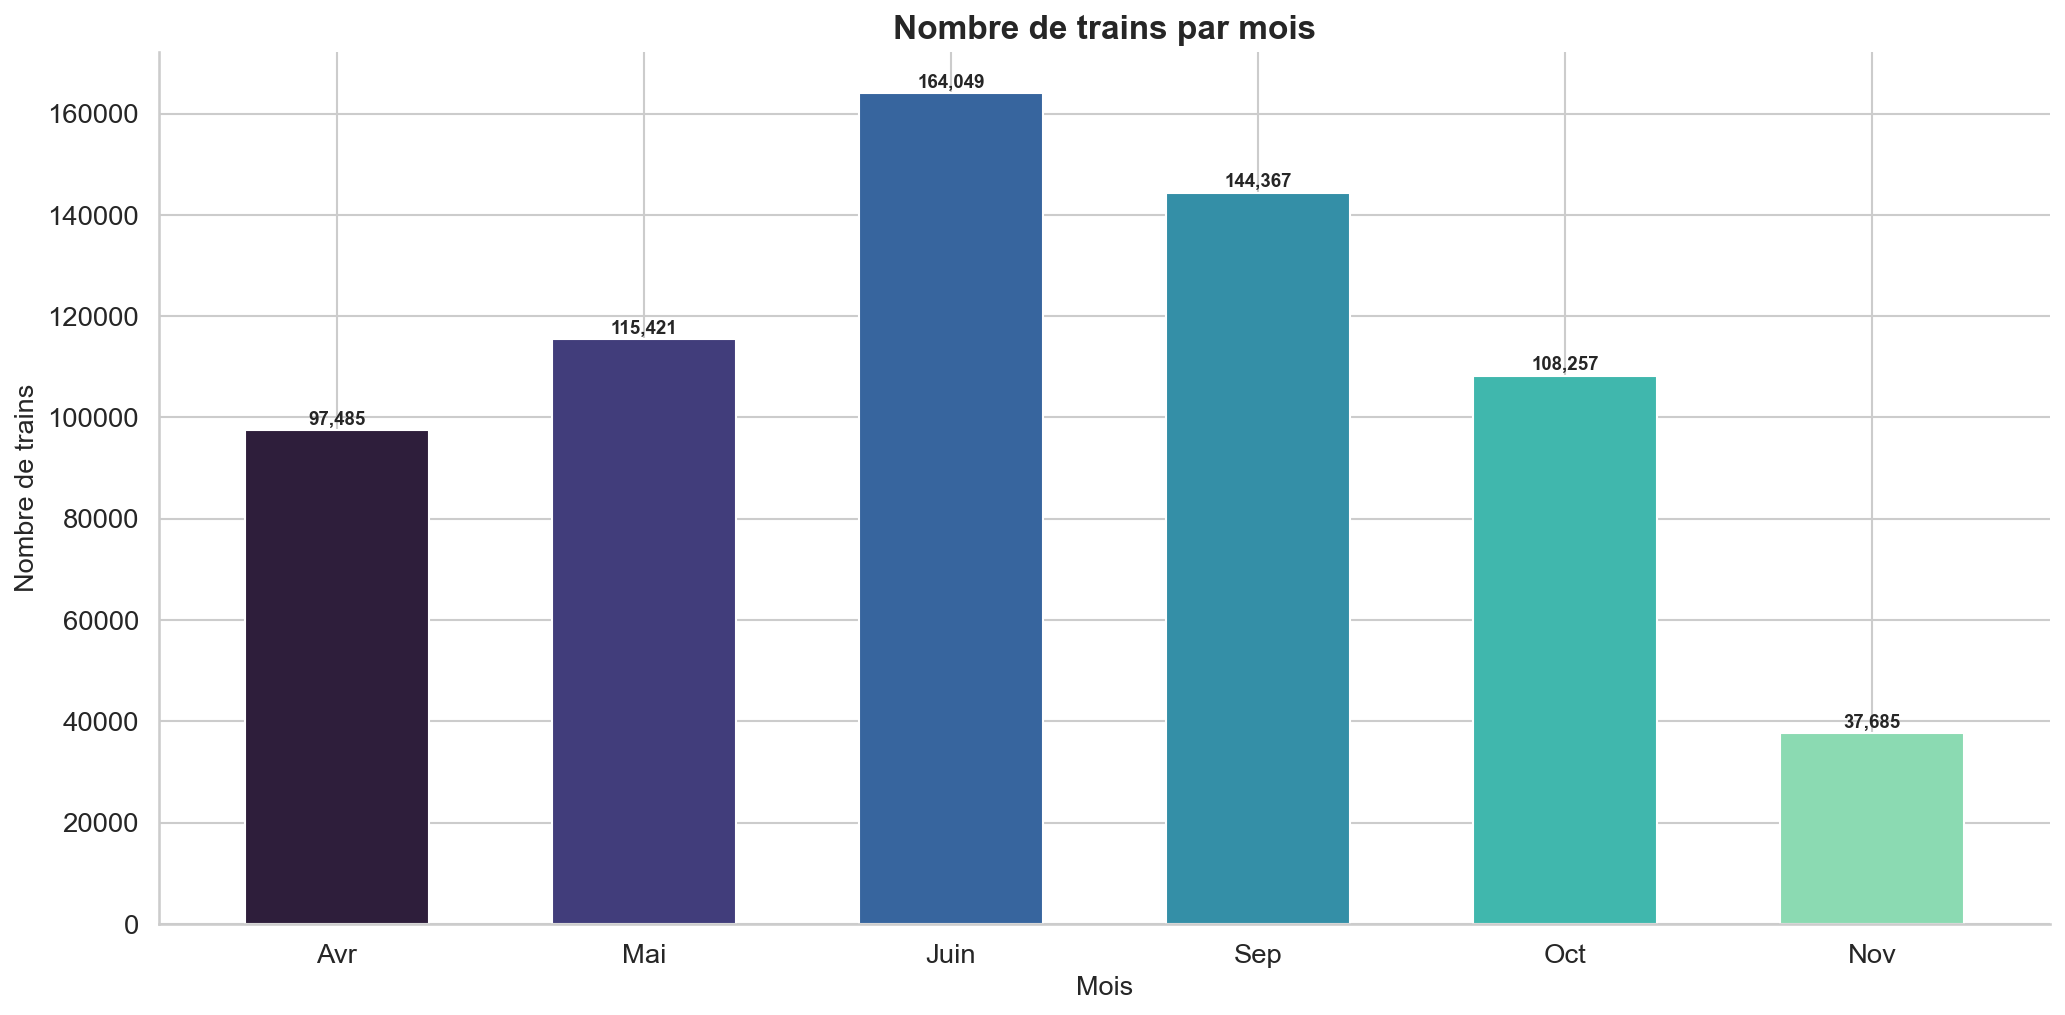

In [141]:
fig, ax = plt.subplots(figsize=(14, 7))
mois_noms = {1: "Jan", 2: "Fév", 3: "Mar", 4: "Avr", 5: "Mai", 6: "Juin",
             7: "Juil", 8: "Août", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Déc"}
month_counts = x_train["month"].value_counts().sort_index()
labels = [mois_noms.get(m, str(m)) for m in month_counts.index]
bars = ax.bar(labels, month_counts.values, color=sns.color_palette("mako", len(month_counts)), edgecolor="white", width=0.6)
ax.set_title("Nombre de trains par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de trains")
ax.spines[["top", "right"]].set_visible(False)
for bar, v in zip(bars, month_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 300, f"{v:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/06_trains_par_mois.png")
plt.show()

In [15]:
# Encodage cyclique
x_train["month_sin"] = np.sin(2 * np.pi * x_train["month"] / 12)
x_train["month_cos"] = np.cos(2 * np.pi * x_train["month"] / 12)
x_train["day_of_week_sin"] = np.sin(2 * np.pi * x_train["day_of_week"] / 5)
x_train["day_of_week_cos"] = np.cos(2 * np.pi * x_train["day_of_week"] / 5)

In [16]:
x_train_cpy = x_train.drop(columns=["Unnamed: 0.1" , "Unnamed: 0" , "year" , "date" , "day_of_week","month" ,"day"])

In [17]:
x_train_cpy

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,VBXNMF,KYF,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,1.000000
1,VBXNMF,JLR,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,1.000000
2,VBXNMF,EOH,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,1.000000
3,VBXNMF,VXY,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,1.000000
4,VBXNMF,OCB,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,BFNJJK,DGG,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.951057,0.309017
667260,BFNJJK,KDN,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.951057,0.309017
667261,BFNJJK,TVD,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.951057,0.309017
667262,BFNJJK,TXP,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.951057,0.309017


In [18]:
# Retard de train : p2q0 . Nous allons fixer la gare s à TVD . retard du train k-2 à la gare s

p2q0 = x_train_cpy[x_train_cpy["gare"] == "TVD"]["p2q0"]

mean_late = p2q0.mean()
max_late = np.abs(p2q0.min())
min_late = p2q0.max()

print(f"Nous avons en moyenne {mean_late} minutes de retard pour la gare TVD !")
print(f"Nous avons au maximum {max_late} minutes de retard pour la gare TVD ! ")
print(f"Nous avons au maximum {min_late} minutes d'avance pour la gare TVD ! ")

Nous avons en moyenne 0.38915675559841423 minutes de retard pour la gare TVD !
Nous avons au maximum 75.0 minutes de retard pour la gare TVD ! 
Nous avons au maximum 5.0 minutes d'avance pour la gare TVD ! 


In [19]:
# Retard du même train k pour toutes les gares qu'il a déja traversées. p0q2 = retard du train k à la gare s-2 . On fixe le train k : PBYUMJ

p0q2 = x_train_cpy[x_train_cpy["train"] == "PBYUMJ"]["p0q2"]

mean_late = p0q2.mean()
max_late = np.abs(p0q2.min())
min_late = p0q2.max()

print(f"Nous avons en moyenne {mean_late} minutes de retard pour le train PBYUMJ pour la gare s-2 !")
print(f"Nous avons au maximum {max_late} minutes de retard pour le train PBYUMJ pour la gare s-2 !")
print(f"Nous avons au maximum {min_late} minutes d'avance pour le train PBYUMJ pour la gare s-2 !")

Nous avons en moyenne -0.2 minutes de retard pour le train PBYUMJ pour la gare s-2 !
Nous avons au maximum 3.0 minutes de retard pour le train PBYUMJ pour la gare s-2 !
Nous avons au maximum 2.0 minutes d'avance pour le train PBYUMJ pour la gare s-2 !


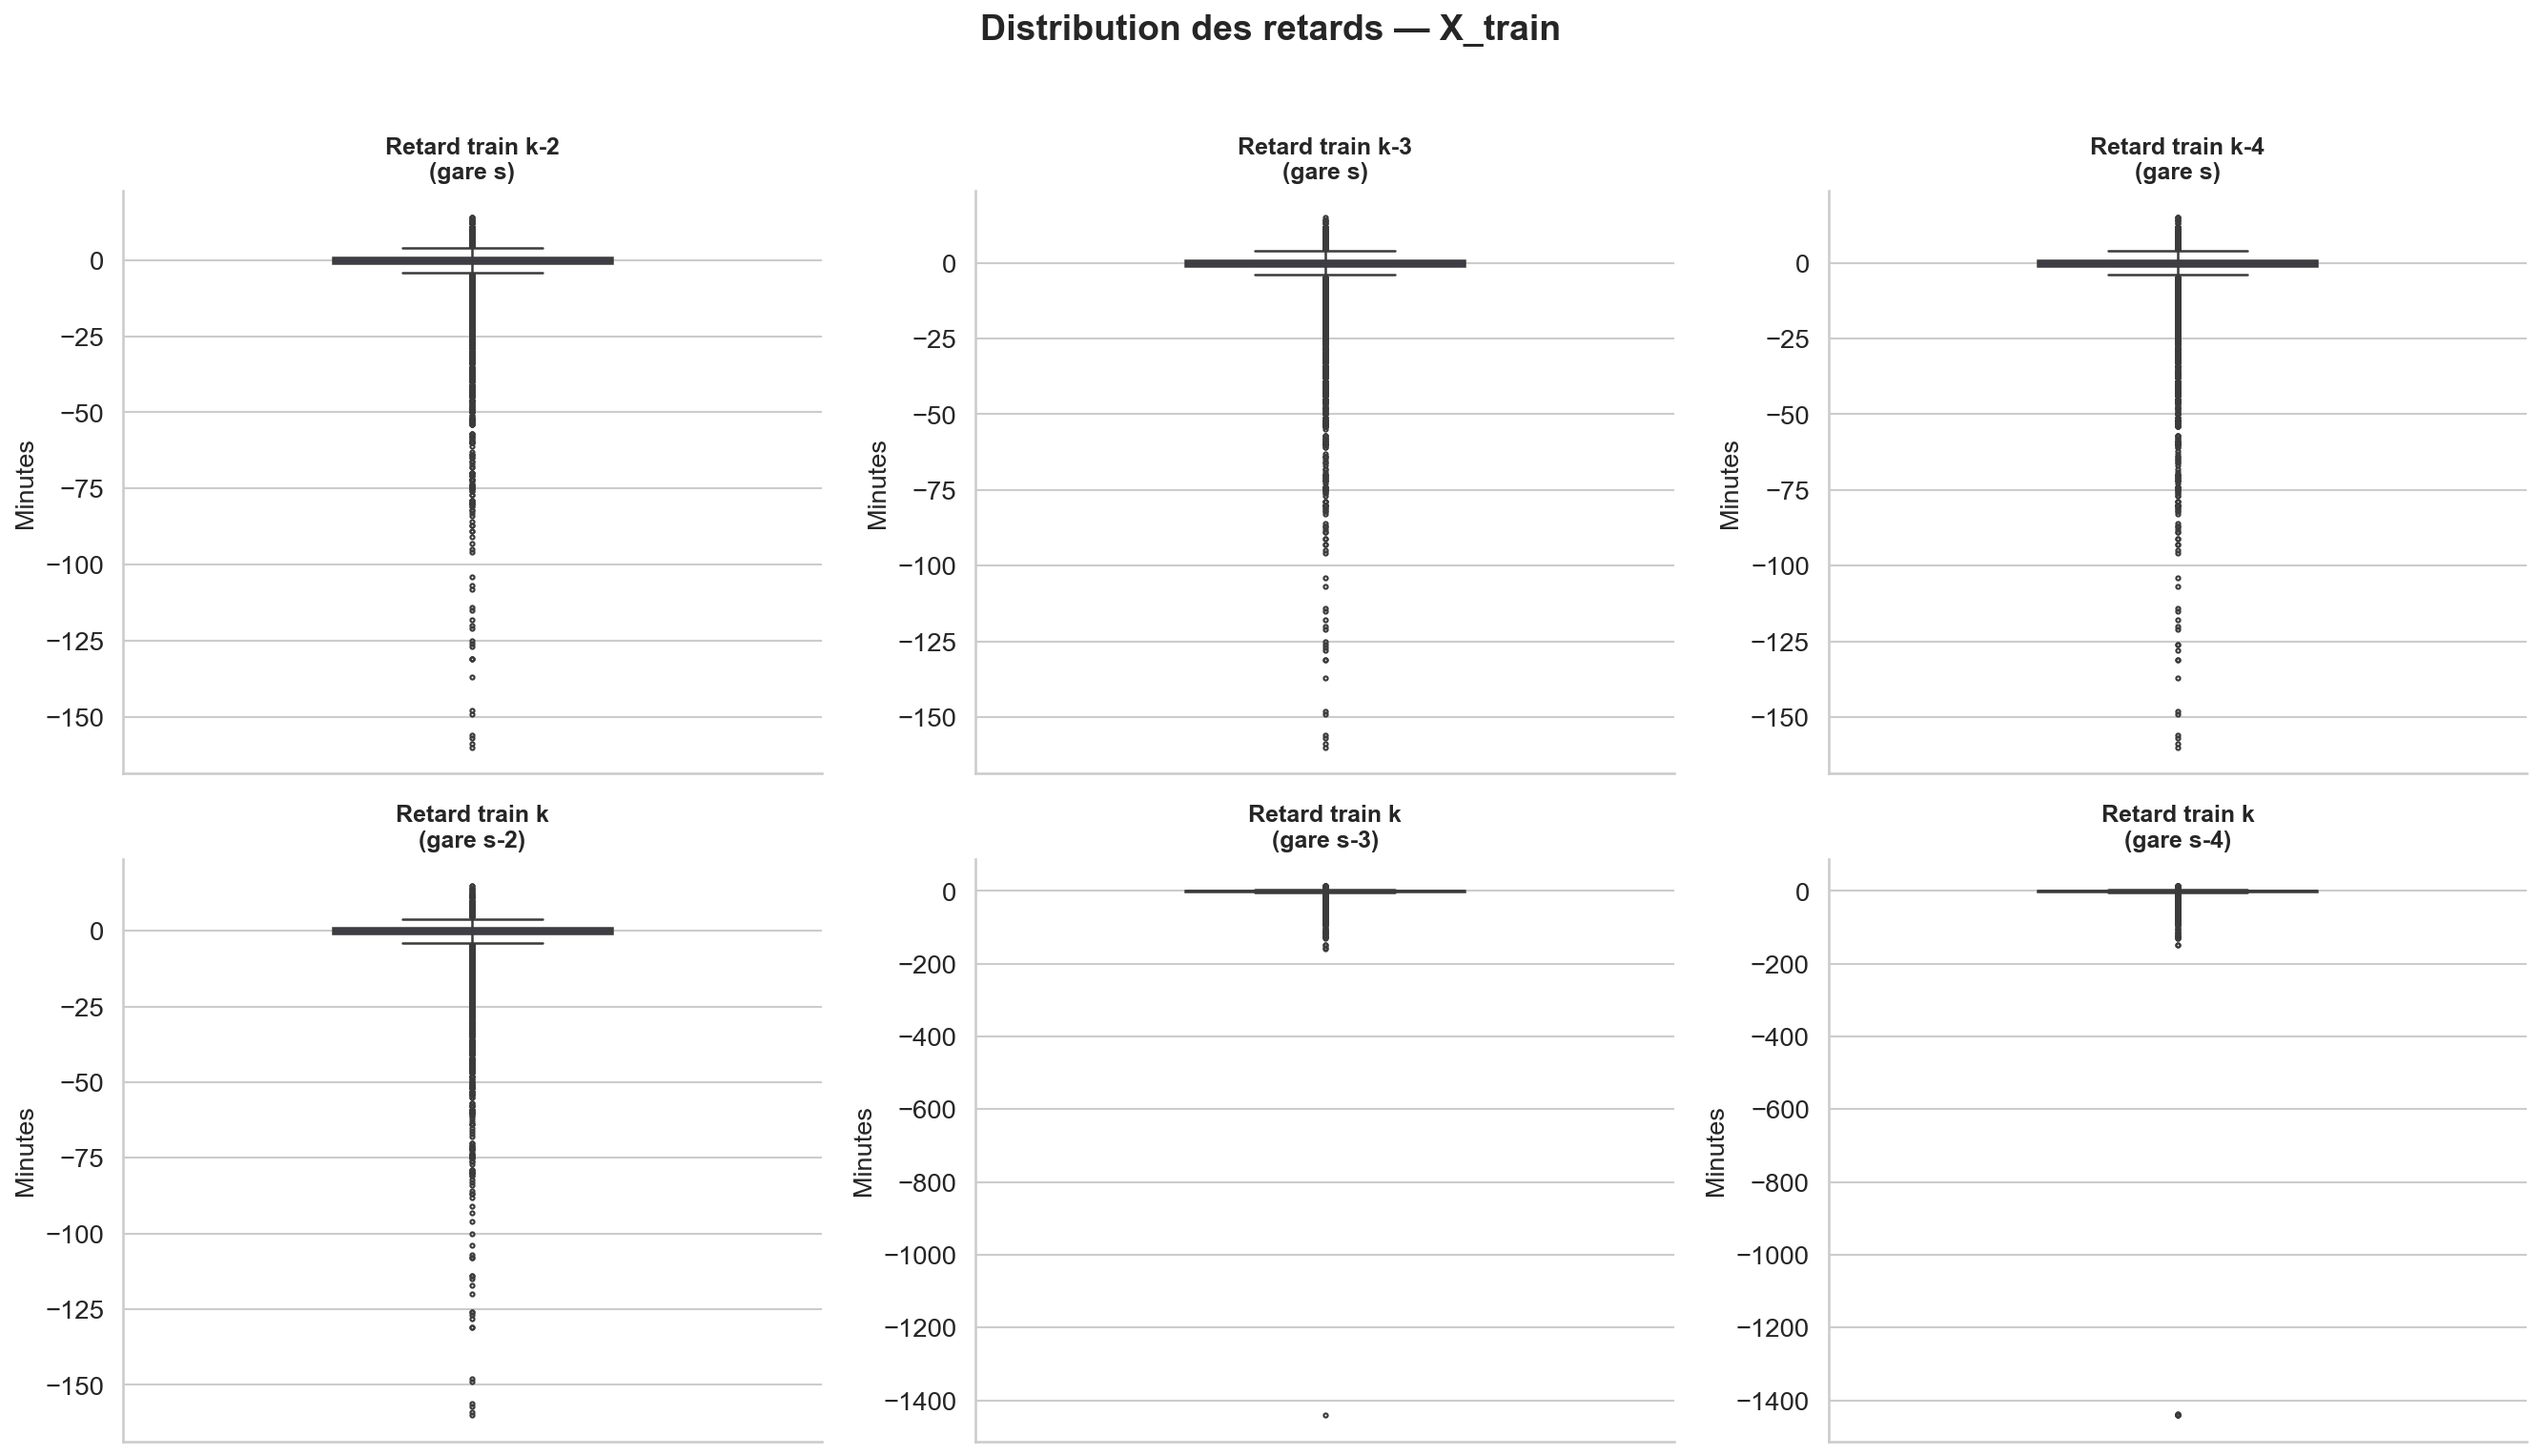

In [142]:
colonnes = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]
labels_cols = {
    "p2q0": "Retard train k-2\n(gare s)",
    "p3q0": "Retard train k-3\n(gare s)",
    "p4q0": "Retard train k-4\n(gare s)",
    "p0q2": "Retard train k\n(gare s-2)",
    "p0q3": "Retard train k\n(gare s-3)",
    "p0q4": "Retard train k\n(gare s-4)",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribution des retards — X_train", fontsize=18, fontweight="bold", y=1.02)

for ax, col in zip(axes.flatten(), colonnes):
    sns.boxplot(y=x_train_cpy[col], ax=ax, color=PALETTE[3], width=0.4, fliersize=2, linewidth=1.2)
    ax.set_title(labels_cols[col], fontsize=12)
    ax.set_ylabel("Minutes")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(f"{SAVE_DIR}/07_boxplots_retards_xtrain.png")
plt.show()

In [26]:
x_train_cpy[x_train_cpy["p0q3"] <= -500]["p0q3"] # A remplacer par un -1 , la moyenne entre p0q2 et p0q4

315111   -1441.0
Name: p0q3, dtype: float64

In [22]:
x_train_cpy[x_train_cpy["p0q4"] <= -500] # # A remplacer par la moyenne entre p0q2 et p0q3

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
115576,LRDJCC,GDN,21,0.0,1.0,1.0,0.0,0.0,-1440.0,5.000000e-01,-0.866025,-0.587785,-0.809017
153537,FTYMLQ,JLR,10,-1.0,-1.0,-1.0,0.0,0.0,-1438.0,5.000000e-01,-0.866025,-0.951057,0.309017
153561,OASJIF,GDN,21,-1.0,0.0,0.0,0.0,1.0,-1439.0,5.000000e-01,-0.866025,-0.951057,0.309017
315121,YQWYHB,AVF,14,0.0,0.0,-1.0,0.0,1.0,-1440.0,1.224647e-16,-1.000000,0.587785,-0.809017
315340,SBVADY,JLR,12,0.0,0.0,-1.0,0.0,0.0,-1440.0,1.224647e-16,-1.000000,0.587785,-0.809017
322157,NOATQT,VXY,15,-1.0,0.0,0.0,0.0,-2.0,-1441.0,1.224647e-16,-1.000000,0.587785,-0.809017


In [125]:
x_test

,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,day,day_of_week
0,0,ZPQEKP,VXY,2023-11-13,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,13,0
1,1,KIQSRA,VXY,2023-11-13,12,0.0,0.0,-1.0,1.0,-1.0,0.0,13,0
2,2,QQJYYT,VXY,2023-11-13,12,0.0,1.0,-1.0,1.0,-1.0,1.0,13,0
3,3,FVKYMZ,VXY,2023-11-13,12,0.0,0.0,-1.0,-1.0,0.0,-1.0,13,0
4,4,GXNZBY,AZA,2023-11-13,12,1.0,-2.0,0.0,0.0,0.0,0.0,13,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20652,20652,GZDMWQ,OJA,2023-12-22,24,-1.0,-1.0,1.0,0.0,1.0,0.0,22,4
20653,20653,DRJDTW,KLN,2023-12-22,12,0.0,0.0,0.0,0.0,0.0,0.0,22,4
20654,20654,DRJDTW,KCK,2023-12-22,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0,22,4
20655,20655,DRJDTW,OJA,2023-12-22,24,-2.0,-2.0,1.0,0.0,0.0,1.0,22,4


In [118]:
x_train_cpy.groupby("train")["arret"].count()["LZOAEF"]

np.int64(21)

## ## Y_TRAIN - VIZ

In [23]:
y_train = pd.read_csv("../data/y_train_final.csv")
y_train = y_train.drop(columns=["Unnamed: 0"])

In [86]:
y_train

,p0q0
0,-1.0
1,-1.0
2,-1.0
3,1.0
4,3.0
...,...
667259,1.0
667260,2.0
667261,2.0
667262,1.0


In [25]:
y_train.describe()

,p0q0
count,667264.000000
mean,-0.159950
std,1.987872
min,-160.000000
25%,-1.000000
50%,0.000000
75%,1.000000
max,15.000000


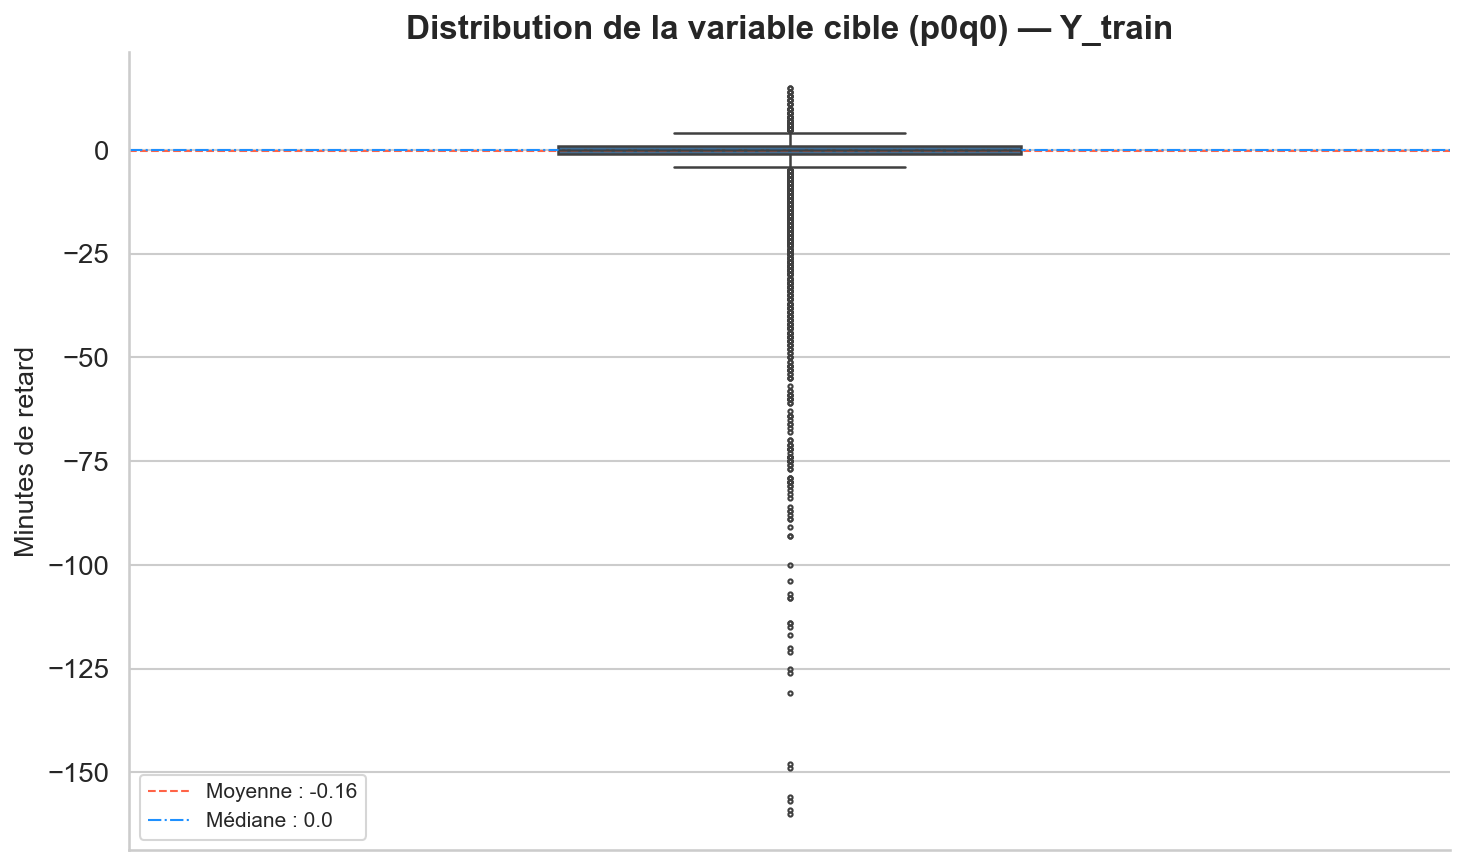

In [143]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y=y_train["p0q0"], ax=ax, color=PALETTE[5], width=0.35, fliersize=2, linewidth=1.2)
ax.set_title("Distribution de la variable cible (p0q0) — Y_train")
ax.set_ylabel("Minutes de retard")
ax.spines[["top", "right"]].set_visible(False)
# Ajouter des stats
median_val = y_train["p0q0"].median()
mean_val = y_train["p0q0"].mean()
ax.axhline(mean_val, color="tomato", linestyle="--", linewidth=1, label=f"Moyenne : {mean_val:.2f}")
ax.axhline(median_val, color="dodgerblue", linestyle="-.", linewidth=1, label=f"Médiane : {median_val:.1f}")
ax.legend(loc="lower left", fontsize=10)
fig.tight_layout()
fig.savefig(f"{SAVE_DIR}/08_boxplot_ytrain.png")
plt.show()

In [29]:
x_test = pd.read_csv("../data/x_test_final.csv")

x_test

,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,ZPQEKP,VXY,2023-11-13,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0
1,1,KIQSRA,VXY,2023-11-13,12,0.0,0.0,-1.0,1.0,-1.0,0.0
2,2,QQJYYT,VXY,2023-11-13,12,0.0,1.0,-1.0,1.0,-1.0,1.0
3,3,FVKYMZ,VXY,2023-11-13,12,0.0,0.0,-1.0,-1.0,0.0,-1.0
4,4,GXNZBY,AZA,2023-11-13,12,1.0,-2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
20652,20652,GZDMWQ,OJA,2023-12-22,24,-1.0,-1.0,1.0,0.0,1.0,0.0
20653,20653,DRJDTW,KLN,2023-12-22,12,0.0,0.0,0.0,0.0,0.0,0.0
20654,20654,DRJDTW,KCK,2023-12-22,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0
20655,20655,DRJDTW,OJA,2023-12-22,24,-2.0,-2.0,1.0,0.0,0.0,1.0


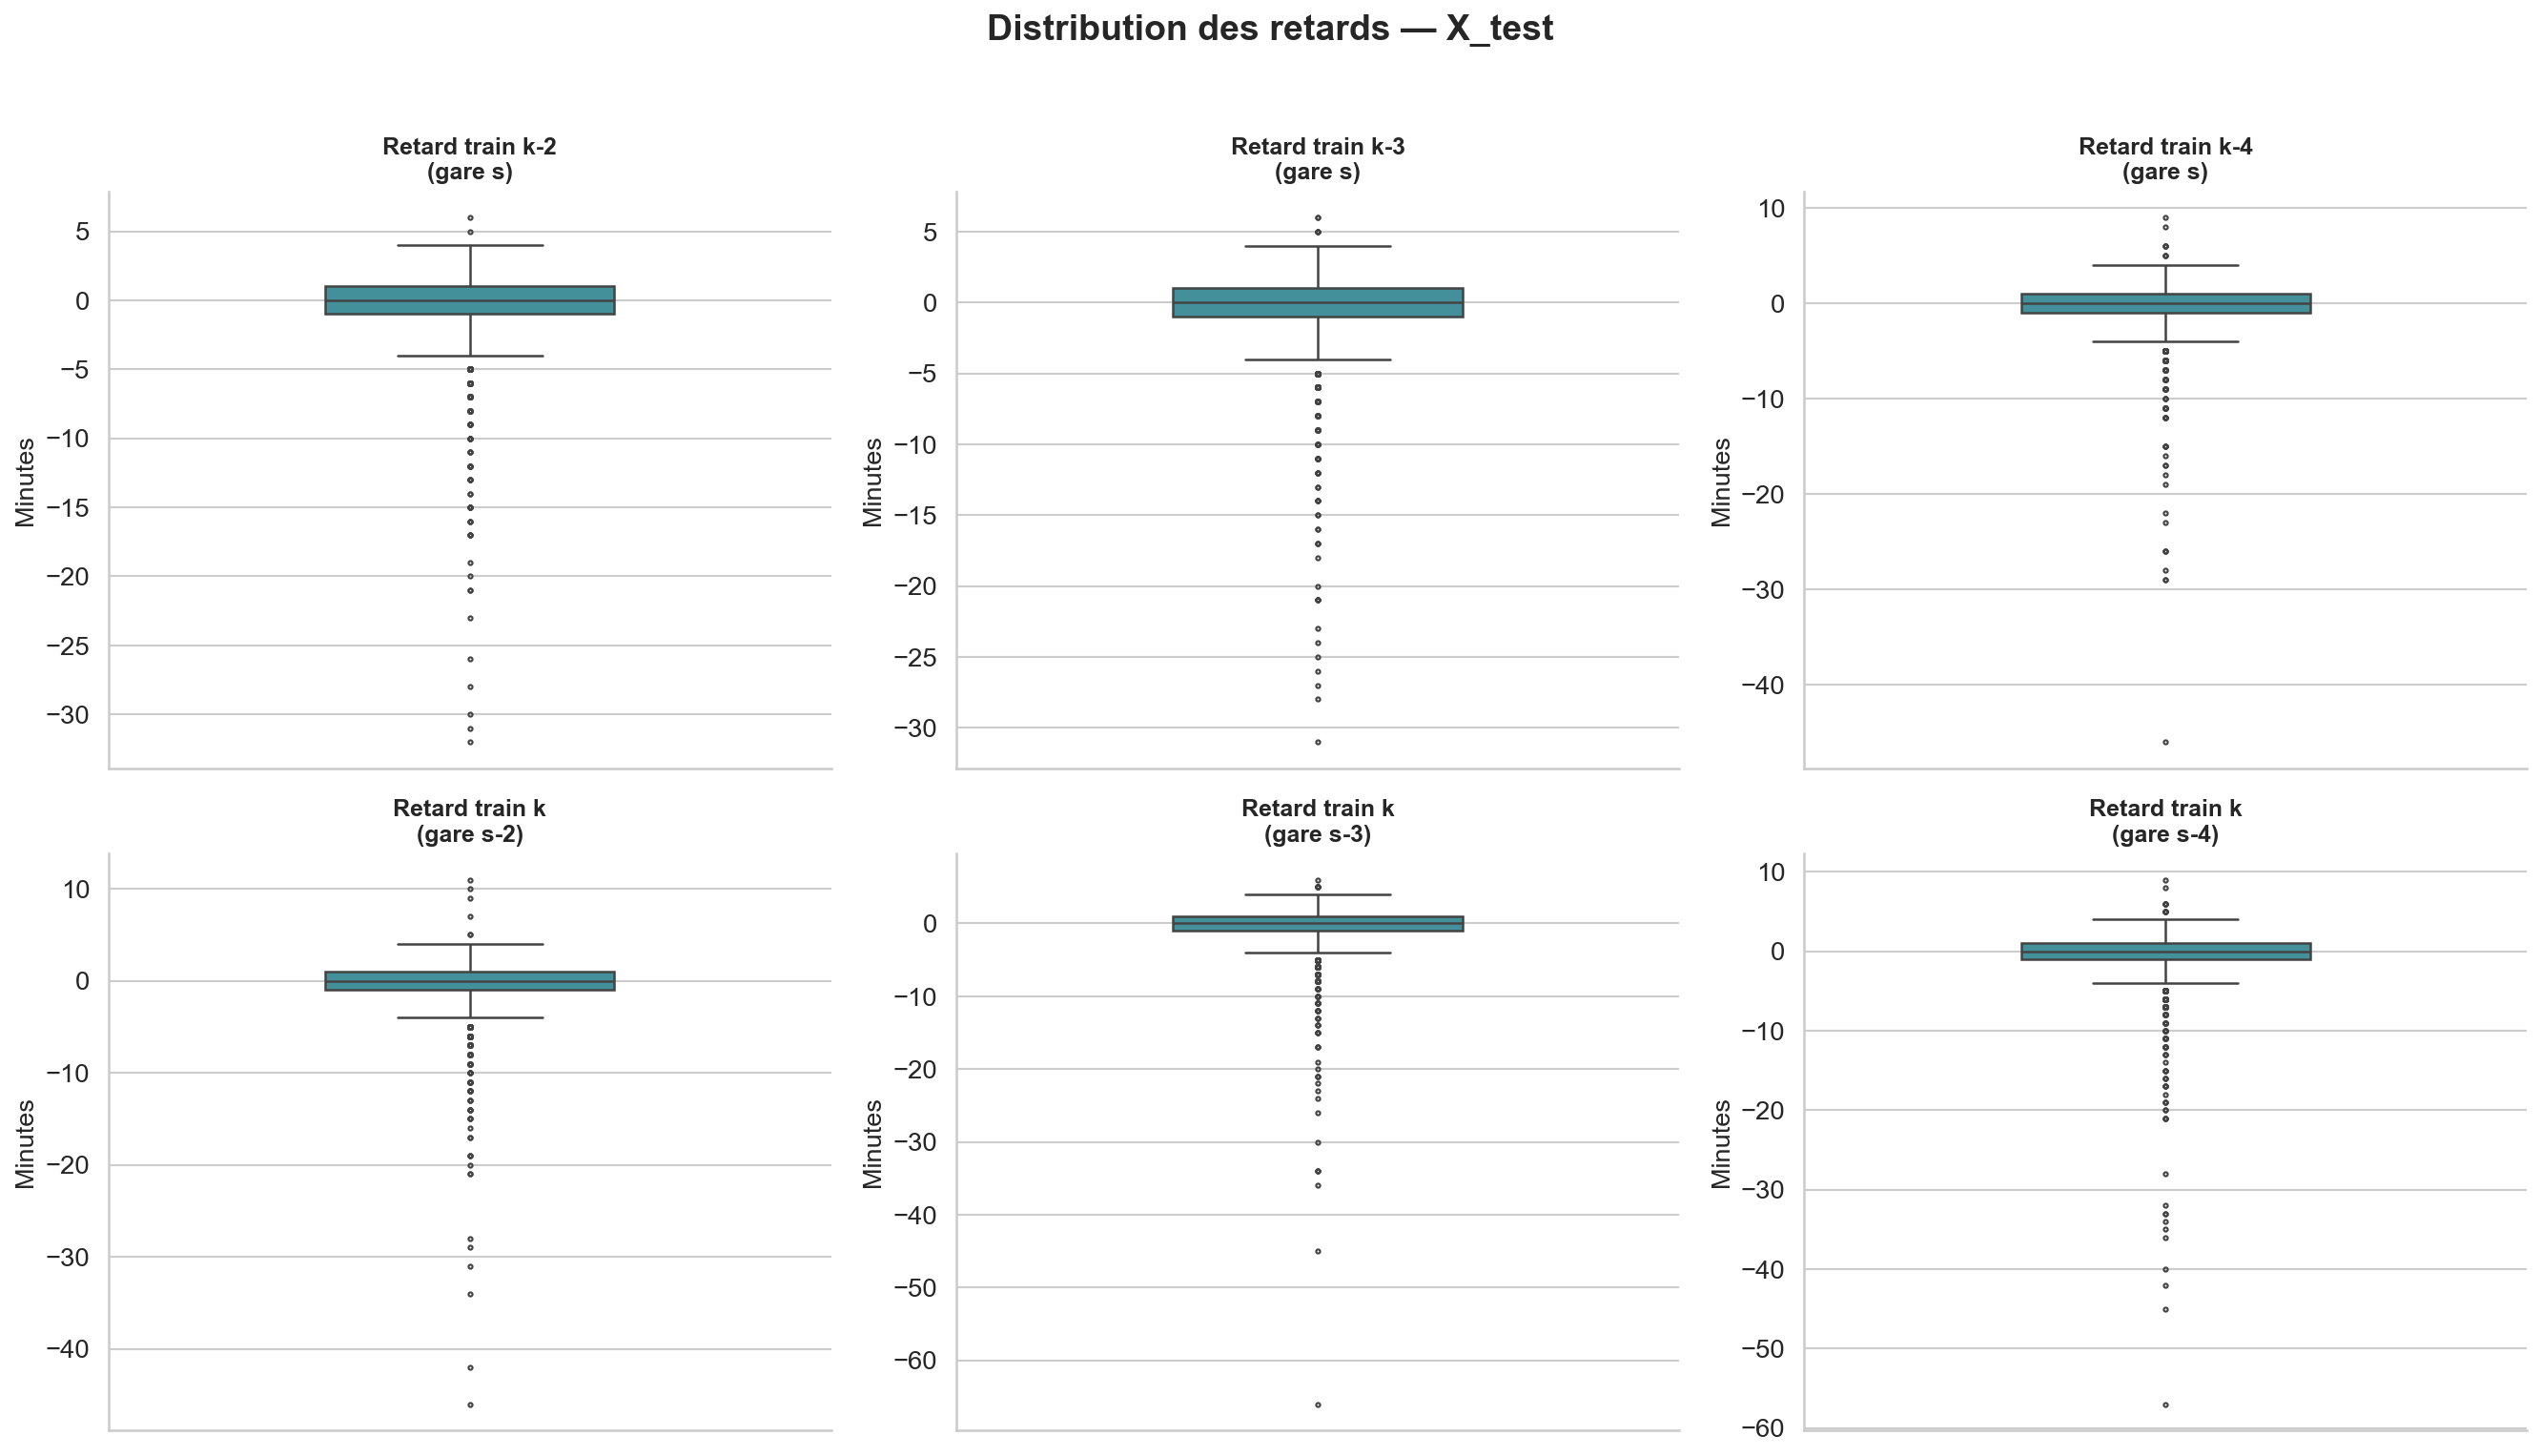

In [144]:
colonnes = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Distribution des retards — X_test", fontsize=18, fontweight="bold", y=1.02)

for ax, col in zip(axes.flatten(), colonnes):
    sns.boxplot(y=x_test[col], ax=ax, color=PALETTE[7], width=0.4, fliersize=2, linewidth=1.2)
    ax.set_title(labels_cols[col], fontsize=12)
    ax.set_ylabel("Minutes")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(f"{SAVE_DIR}/09_boxplots_retards_xtest.png")
plt.show()

# PAS DE VALEUR ABERRANTE POUR X_TEST